# Edge-IIoTset Veri Seti - Keşifçi Veri Analizi (EDA)
Bu notebook'ta Edge-IIoTset siber güvenlik veri setini inceleyecek, eksik verileri kontrol edecek ve sınıf dağılımlarını görselleştireceğiz.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ayarları
plt.style.use('ggplot')
sns.set_palette("husl")

In [2]:
data_path = "../data/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv" 
print("Veri yükleniyor, lütfen bekleyin...")
try:
    df = pd.read_csv(data_path, low_memory=False)
    print(f"Veri başarıyla yüklendi! Toplam satır: {df.shape[0]}, Toplam kolon: {df.shape[1]}")
except FileNotFoundError:
    print("Hata: Veri dosyası bulunamadı. Lütfen 'data/raw/' klasöründe dosyanın olduğundan emin ol.")

Veri yükleniyor, lütfen bekleyin...
Veri başarıyla yüklendi! Toplam satır: 157800, Toplam kolon: 63


In [3]:
# İlk İnceleme
if 'df' in locals():
    display(df.head())
    print("\n--- Veri Tipleri ve Boş Değerler ---")
    df.info()

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM



--- Veri Tipleri ve Boş Değerler ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157800 entries, 0 to 157799
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame.time                 157800 non-null  object 
 1   ip.src_host                157800 non-null  object 
 2   ip.dst_host                157800 non-null  object 
 3   arp.dst.proto_ipv4         157800 non-null  object 
 4   arp.opcode                 157800 non-null  float64
 5   arp.hw.size                157800 non-null  float64
 6   arp.src.proto_ipv4         157800 non-null  object 
 7   icmp.checksum              157800 non-null  float64
 8   icmp.seq_le                157800 non-null  float64
 9   icmp.transmit_timestamp    157800 non-null  float64
 10  icmp.unused                157800 non-null  float64
 11  http.file_data             157800 non-null  object 
 12  http.content_length        157800 non-null  floa

In [4]:
# Eksik Değer (NaN) Analizi Yüzdesi
if 'df' in locals():
    missing_percentages = (df.isnull().sum() / len(df)) * 100
    missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

    print("\n--- Eksik Değer Yüzdeleri ---")
    print(missing_percentages if not missing_percentages.empty else "Hiç eksik veri yok! Harika.")


--- Eksik Değer Yüzdeleri ---
Hiç eksik veri yok! Harika.


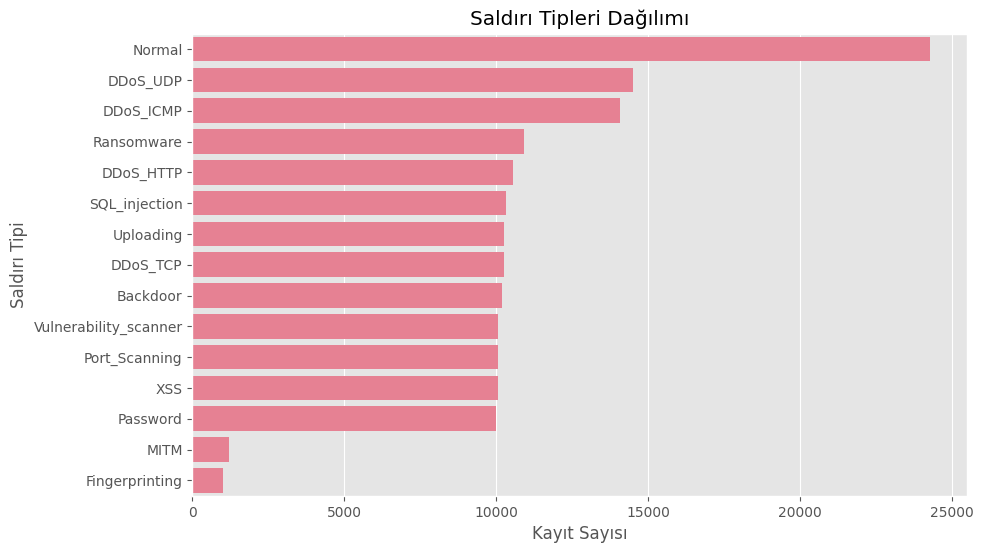

In [5]:
# Sınıf Dağılımı (Normal vs Saldırı)
# Hedef değişkenimiz veri setine göre 'Attack_type' veya 'Attack_label' olabilir.
if 'df' in locals():
    plt.figure(figsize=(10, 6))
    if 'Attack_type' in df.columns:
        sns.countplot(data=df, y='Attack_type', order=df['Attack_type'].value_counts().index)
        plt.title("Saldırı Tipleri Dağılımı")
        plt.xlabel("Kayıt Sayısı")
        plt.ylabel("Saldırı Tipi")
        plt.show()
    else:
        print("'Attack_type' kolonu bulunamadı. Lütfen hedef kolonun adını kontrol edip düzeltin.")

In [6]:
# 14+ Saldırı Tipi Frekansı (Rakam ve Yüzdelikler)
if 'df' in locals() and 'Attack_type' in df.columns:
    attack_counts = df['Attack_type'].value_counts()
    attack_percentages = df['Attack_type'].value_counts(normalize=True) * 100
    attack_stats = pd.DataFrame({
        'Kayıt Sayısı': attack_counts,
        'Yüzde (%)': attack_percentages
    })
    print("\n--- Saldırı Tipleri Frekans Tablosu ---")
    display(attack_stats)


--- Saldırı Tipleri Frekans Tablosu ---


,Kayıt Sayısı,Yüzde (%)
Attack_type,,
Normal,24301,15.399873
DDoS_UDP,14498,9.187579
DDoS_ICMP,14090,8.929024
Ransomware,10925,6.923321
DDoS_HTTP,10561,6.692649
SQL_injection,10311,6.534221
Uploading,10269,6.507605
DDoS_TCP,10247,6.493663
Backdoor,10195,6.460710


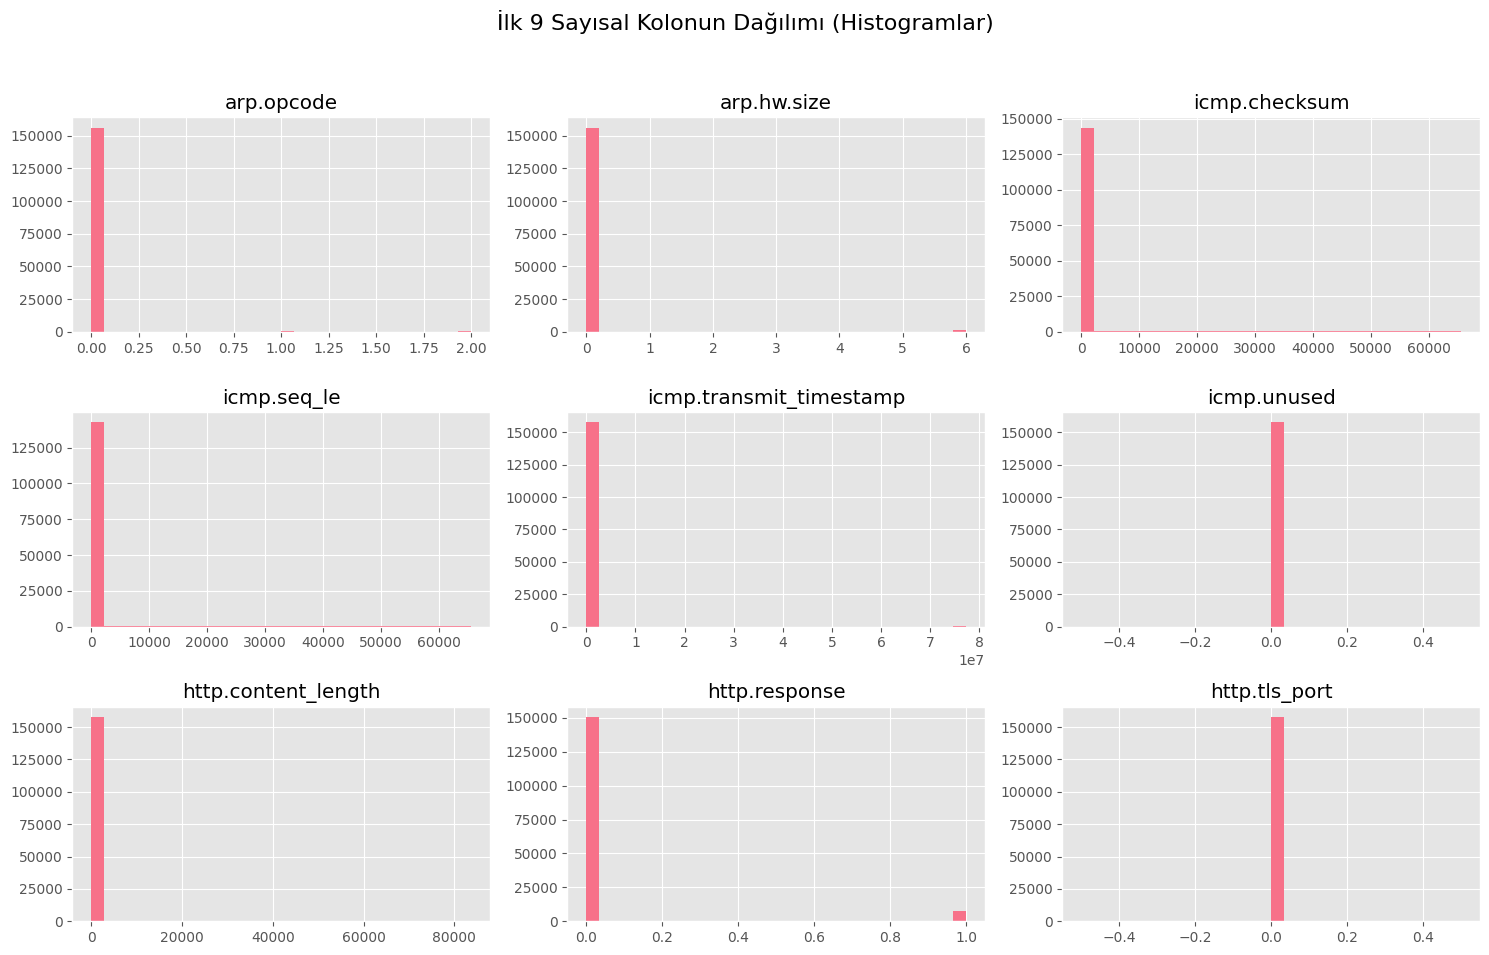

In [7]:
# Sayısal Kolon Histogramları
# 40'tan fazla kolon olduğu için ilk 9 float64 tipindeki kolonu görselleştirelim
if 'df' in locals():
    numeric_cols = df.select_dtypes(include=['float64']).columns
    cols_to_plot = numeric_cols[:9]
    
    df[cols_to_plot].hist(bins=30, figsize=(15, 10))
    plt.suptitle('İlk 9 Sayısal Kolonun Dağılımı (Histogramlar)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

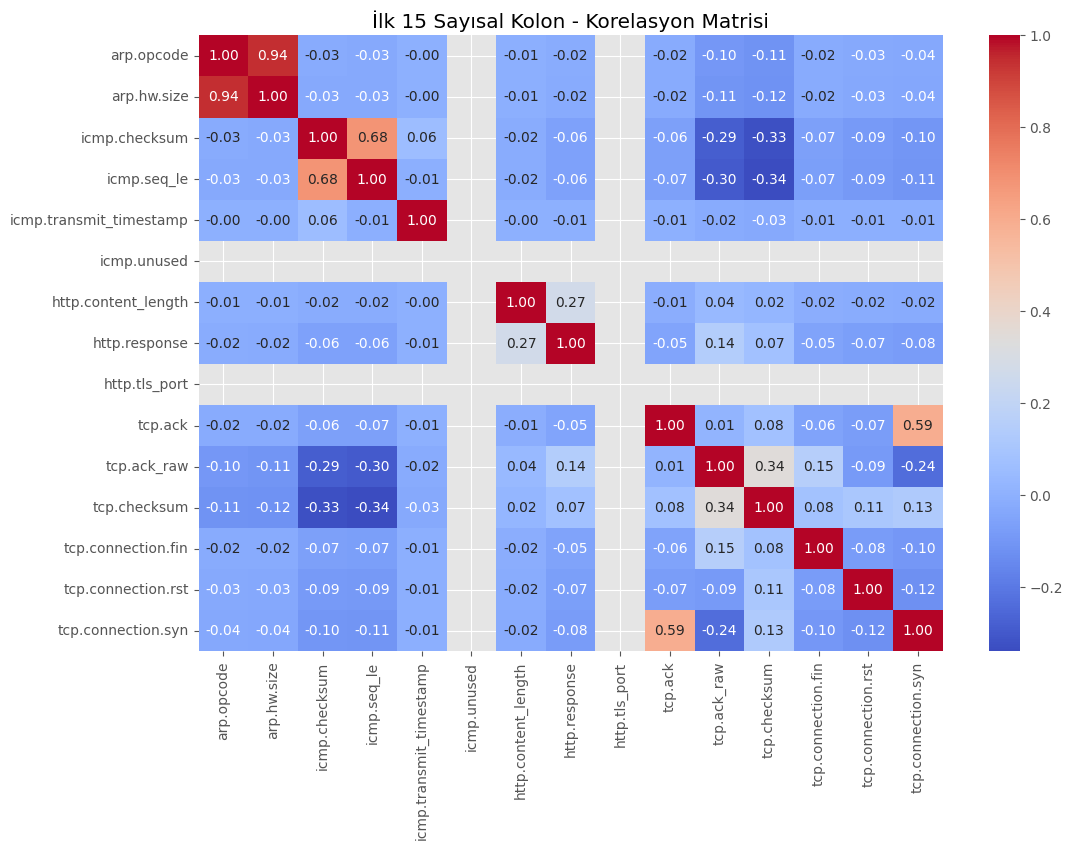

In [8]:
# Korelasyon Matrisi (Heatmap)
if 'df' in locals():
    # Okunabilirliği artırmak için ilk 15 float64 kolonu arasındaki korelasyona bakalım
    numeric_cols = df.select_dtypes(include=['float64']).columns
    cols_for_corr = numeric_cols[:15]
    
    plt.figure(figsize=(12, 8))
    corr_matrix = df[cols_for_corr].corr()
    
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title("İlk 15 Sayısal Kolon - Korelasyon Matrisi")
    plt.show()